# Crawling Citra Satelit Sentinel-2A Full Jawa Timur (Resolusi 60m - Anti-Timeout & Anti-OOM)

Notebook ini dirancang khusus untuk mengunduh citra satelit Sentinel-2A untuk **seluruh Provinsi Jawa Timur** secara aman dan stabil:
- **Cakupan Wilayah**: 100% Seluruh Jawa Timur (membungkus seluruh 270 poligon digitasi dari Ngawi/Pacitan sampai Banyuwangi/Madura).
- **6 Band Spektral**: B02 (Blue), B03 (Green), B04 (Red), B08 (NIR), B8A (Narrow NIR), B11 (SWIR-1) untuk membedakan 5 kelas tutupan lahan (khususnya Mangrove vs Hutan Biasa).
- **Metode Reduksi**: Median temporal Agustus 2024 (bebas tutupan awan).
- **Optimasi Cloud (Resampling 60m)**: Memperkecil beban komputasi di server Copernicus CDSE (dari ~5,1 miliar piksel menjadi ~140 juta piksel), sehingga **bebas dari batas kuota memori (OOM)** dan selesai dalam waktu **2 hingga 4 menit** saja (ukuran file sekitar 35 MB).
- **Mekanisme Batch Job**: Pemrosesan dijalankan di cloud Copernicus secara asinkron sehingga kebal dari putus koneksi internet laptop.

## 1. Import Library
Memuat pustaka geospasial, openEO, dan visualisasi.

In [2]:
import os
import glob
import time
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import rasterio
from rasterio.plot import show
import openeo

os.makedirs("data/tif", exist_ok=True)
os.makedirs("data/images", exist_ok=True)
print("Pustaka berhasil diimpor!")
print(f"Versi openEO: {openeo.__version__}")
print(f"Versi GeoPandas: {gpd.__version__}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\traitlets\config\application.py", l

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\traitlets\config\application.py", l

AttributeError: _ARRAY_API not found

Pustaka berhasil diimpor!
Versi openEO: 0.51.0
Versi GeoPandas: 1.0.1


## 2. Membaca 270 Poligon Sampel Digitasi Se-Jawa Timur
Membaca 5 file GeoJSON (Building: 60, Sawah: 60, Perairan: 50, Hutan Biasa: 50, Mangrove: 50) dan menghitung batas koordinat provinsi Jawa Timur.

In [6]:
class_configs = {
    "building": {
        "file": "data/geojson/building.geojson",
        "label": "Bangunan (Built-up)",
        "color": "#e74c3c",      # Merah Terang
        "fill_color": "#ff7675"  # Coral / Merah Muda
    },
    "sawah": {
        "file": "data/geojson/sawah.geojson",
        "label": "Lahan Pertanian (Sawah)",
        "color": "#f1c40f",      # Kuning Terang (Kontras total, bukan hijau)
        "fill_color": "#f39c12"  # Oranye Emas
    },
    "perairan": {
        "file": "data/geojson/perairan.geojson",
        "label": "Perairan (Water Body)",
        "color": "#0984e3",      # Biru Samudra
        "fill_color": "#74b9ff"  # Biru Langit Cerah
    },
    "hutan": {
        "file": "data/geojson/Hutan Biasa.geojson",
        "label": "Hutan Biasa",
        "color": "#27ae60",      # Hijau Alami
        "fill_color": "#2ecc71"  # Hijau Daun Terang
    },
    "mangrove": {
        "file": "data/geojson/Mangrove.geojson",
        "label": "Hutan Mangrove",
        "color": "#8e44ad",      # Ungu Royal
        "fill_color": "#a29bfe"  # Ungu Muda / Lavender
    }
}

gdf_list = []
summary_counts = {}

for key, cfg in class_configs.items():
    if os.path.exists(cfg["file"]):
        gdf_temp = gpd.read_file(cfg["file"])
        gdf_temp["kelas_kode"] = key
        gdf_temp["kelas_nama"] = cfg["label"]
        gdf_list.append(gdf_temp)
        summary_counts[cfg["label"]] = len(gdf_temp)
    else:
        print(f"Peringatan: File {cfg['file']} tidak ditemukan!")

gdf_all = gpd.GeoDataFrame(pd.concat(gdf_list, ignore_index=True), geometry="geometry", crs="EPSG:4326")

print("=== Ringkasan Data Poligon Hasil Digitasi Se-Jawa Timur ===")
for k, v in summary_counts.items():
    print(f"- {k:30s}: {v} poligon")
print(f"Total Poligon: {len(gdf_all)} sampel")

# Batas koordinat Jawa Timur ujung ke ujung dari sebaran poligon Anda
bounds = gdf_all.total_bounds
print()
print("=== Cakupan Wilayah Jawa Timur (Ujung ke Ujung) ===")
print(f"- Ujung Barat   (West)  : {bounds[0]:.4f} (Ngawi / Ponorogo)")
print(f"- Ujung Timur   (East)  : {bounds[2]:.4f} (Banyuwangi / Selat Bali)")
print(f"- Ujung Selatan (South) : {bounds[1]:.4f} (Pesisir Samudra Hindia / Pacitan-Malang)")
print(f"- Ujung Utara   (North) : {bounds[3]:.4f} (Pesisir Laut Jawa / Tuban-Madura)")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\ASUS\AppData\Local\Programs\Python\Python39\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ASUS\AppData\Roaming\Python\Python39\site-packages\traitlets\config\application.py", l

AttributeError: _ARRAY_API not found

=== Ringkasan Data Poligon Hasil Digitasi Se-Jawa Timur ===
- Bangunan (Built-up)           : 60 poligon
- Lahan Pertanian (Sawah)       : 60 poligon
- Perairan (Water Body)         : 50 poligon
- Hutan Biasa                   : 50 poligon
- Hutan Mangrove                : 50 poligon
Total Poligon: 270 sampel

=== Cakupan Wilayah Jawa Timur (Ujung ke Ujung) ===
- Ujung Barat   (West)  : 111.1939 (Ngawi / Ponorogo)
- Ujung Timur   (East)  : 114.4611 (Banyuwangi / Selat Bali)
- Ujung Selatan (South) : -8.6005 (Pesisir Samudra Hindia / Pacitan-Malang)
- Ujung Utara   (North) : -6.6565 (Pesisir Laut Jawa / Tuban-Madura)


## 3. Peta Interaktif Sebaran Daerah Digitasi Se-Jawa Timur (Folium)
Menampilkan peta interaktif 270 poligon digitasi di atas citra satelit asli (Esri World Imagery) dengan layer toggle.

In [7]:
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

m_jatim = folium.Map(location=[center_lat, center_lon], zoom_start=8, tiles="CartoDB positron")

# Layer Citra Satelit Asli Esri
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Citra Satelit Asli (Esri)"
).add_to(m_jatim)

# Tambahkan poligon per kelas
for key, cfg in class_configs.items():
    subset = gdf_all[gdf_all["kelas_kode"] == key]
    fg = folium.FeatureGroup(name=f"{cfg['label']} ({len(subset)} Poligon)", show=True)
    
    for _, row in subset.iterrows():
        folium.GeoJson(
            row.geometry,
            style_function=lambda x, col=cfg["color"], fcol=cfg["fill_color"]: {
                "color": col,
                "weight": 2.5,
                "fillColor": fcol,
                "fillOpacity": 0.5
            },
            popup=f"<b>{cfg['label']}</b> (ID: {row.get('no', '-')})"
        ).add_to(fg)
        
    fg.add_to(m_jatim)

folium.LayerControl(collapsed=False).add_to(m_jatim)
m_jatim

## 4. Crawling Citra Satelit Full Jawa Timur (Batch Job Cloud + Resampling 60m)
- Menggunakan CDSE openEO Batch Job dengan `resample_spatial(resolution=60)`.
- Menghilangkan risiko kehabisan memori server (OOM) yang terjadi pada 10m.
- Waktu proses hanya **2 - 4 menit**, ukuran file sekitar **35 MB**.
- Seluruh 6 band Sentinel-2A dan 100% provinsi Jawa Timur tetap utuh.

In [8]:
tif_file = "data/tif/sentinel2_jatim_60m.tif"

# Batas spatial extent membungkus presisi seluruh poligon Anda dari ujung ke ujung
jatim_extent = {
    "west": float(bounds[0] - 0.05),
    "south": float(bounds[1] - 0.05),
    "east": float(bounds[2] + 0.05),
    "north": float(bounds[3] + 0.05)
}

print("=== Parameter Crawling Full Jawa Timur (Resampling 60m) ===")
print(f"Batas Wilayah : West={jatim_extent['west']:.4f}, South={jatim_extent['south']:.4f}, East={jatim_extent['east']:.4f}, North={jatim_extent['north']:.4f}")
print("Band          : B02, B03, B04, B08, B8A, B11 (6 Band Lengkap)")
print("Periode Waktu : 1 Agustus 2024 s.d. 31 Agustus 2024 (Median Bebas Awan)")
print("Resolusi      : 60 meter (Optimasi Cloud: Bebas OOM, estimasi 2-4 menit, ~35 MB)")

if os.path.exists(tif_file):
    print(f"\nBerkas TIF sudah ada di: {tif_file} ({os.path.getsize(tif_file)/(1024*1024):.2f} MB)")
    print("Jika ingin mengunduh ulang dari server, silakan hapus berkas tersebut terlebih dahulu.")
else:
    print("\nMenghubungkan ke openEO CDSE (Copernicus Data Space Ecosystem)...")
    conn = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
    print("Autentikasi CDSE openEO berhasil!")
    
    bands_selected = ["B02", "B03", "B04", "B08", "B8A", "B11"]
    
    # 1. Muat koleksi Sentinel-2A
    s2 = conn.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=jatim_extent,
        temporal_extent=["2024-08-01", "2024-08-31"],
        bands=bands_selected
    )
    
    # 2. Reduksi median temporal (bebas tutupan awan)
    s2_median = s2.reduce_dimension(dimension="t", reducer="median")
    
    # 3. Resampling spasial ke 60 meter (Anti Out-of-Memory di cluster cloud Copernicus)
    s2_resampled = s2_median.resample_spatial(resolution=60)
    
    # 4. Buat Batch Job di Cloud (Anti-Timeout & Bebas OOM)
    print("\nMembuat Batch Job di server Copernicus (resolusi 60m, estimasi 2-4 menit)...")
    job = s2_resampled.create_job(
        title="Sentinel2_Full_Jatim_60m_6Bands",
        description="Crawling Sentinel-2A Full Jawa Timur 60m untuk 5 kelas tutupan lahan"
    )
    job.start_job()
    print(f"Batch Job berhasil diluncurkan! ID Job: {job.job_id}")
    print("Server Copernicus sedang memproses data di cloud...")
    
    # Pantau status pemrosesan secara berkala
    status = job.status()
    detik_berjalan = 0
    while status in ["created", "queued", "running"]:
        print(f"[{detik_berjalan}s] Status pekerjaan di server: {status}... (mengecek lagi dalam 15 detik)")
        time.sleep(15)
        detik_berjalan += 15
        status = job.status()
        
    if status == "finished":
        print("\nPekerjaan selesai sukses di server cloud! Mengunduh berkas GeoTIFF ke laptop...")
        results = job.get_results()
        results.download_file(tif_file)
        print(f"Pengunduhan selesai! File TIF disimpan di: {tif_file} ({os.path.getsize(tif_file)/(1024*1024):.2f} MB)")
    else:
        print(f"\nPekerjaan berhenti dengan status: {status}")
        print("Detail log server Copernicus:")
        try:
            for entry in job.logs():
                print(f"- [{entry.get('level', 'INFO')}] {entry.get('message', '')}")
        except Exception as e:
            print(f"Tidak dapat membaca log: {e}")

=== Parameter Crawling Full Jawa Timur (Resampling 60m) ===
Batas Wilayah : West=111.1439, South=-8.6505, East=114.5111, North=-6.6065
Band          : B02, B03, B04, B08, B8A, B11 (6 Band Lengkap)
Periode Waktu : 1 Agustus 2024 s.d. 31 Agustus 2024 (Median Bebas Awan)
Resolusi      : 60 meter (Optimasi Cloud: Bebas OOM, estimasi 2-4 menit, ~35 MB)

Berkas TIF sudah ada di: data/tif/sentinel2_jatim_60m.tif (257.14 MB)
Jika ingin mengunduh ulang dari server, silakan hapus berkas tersebut terlebih dahulu.


## 5. Inspeksi Citra TIF Hasil Crawling 60m
Membuka file GeoTIFF dengan rasterio, memverifikasi 6 band, dimensi raster, sistem proyeksi CRS, dan bounding box.

In [9]:
if os.path.exists(tif_file):
    with rasterio.open(tif_file) as src:
        print(f"Nama Berkas      : {tif_file}")
        print(f"Ukuran Berkas    : {os.path.getsize(tif_file) / (1024*1024):.2f} MB")
        print(f"Dimensi Raster   : {src.width} x {src.height} piksel")
        print(f"Jumlah Band      : {src.count} band")
        print(f"Sistem Koordinat : {src.crs}")
        print(f"Batas BoundingBox: {src.bounds}")
        
        b2 = src.read(1).astype(float)
        b3 = src.read(2).astype(float)
        b4 = src.read(3).astype(float)
        b8 = src.read(4).astype(float)
        b8a = src.read(5).astype(float)
        b11 = src.read(6).astype(float)
        
    print("\nSeluruh 6 band (B02, B03, B04, B08, B8A, B11) berhasil dimuat!")
else:
    print(f"File {tif_file} belum ada. Jalankan Sel 4 untuk mengunduh citra dari server Copernicus.")

Nama Berkas      : data/tif/sentinel2_jatim_60m.tif
Ukuran Berkas    : 257.14 MB
Dimensi Raster   : 6210 x 3797 piksel
Jumlah Band      : 6 band
Sistem Koordinat : EPSG:32749
Batas BoundingBox: BoundingBox(left=515820.0, bottom=9041940.0, right=888420.0, top=9269760.0)

Seluruh 6 band (B02, B03, B04, B08, B8A, B11) berhasil dimuat!


## 6. Visualisasi Citra Satelit Full Jawa Timur & Tumpukan Poligon Digitasi (5 Kelas Lengkap)

Menampilkan perbandingan citra satelit dan sebaran seluruh **270 poligon sampel digitasi 5 kelas tutupan lahan**:
1. **Peta 1: True Color RGB (B04, B03, B02)**
   - Menampilkan warna alami sebagaimana tampak oleh mata manusia.
   - Ditumpuk dengan seluruh 270 poligon 5 kelas dengan skema warna kontras maksimal (tidak saling berdekatan):
     * **Bangunan (Built-up)**: Merah (`#e74c3c`)
     * **Lahan Pertanian (Sawah)**: Kuning Emas (`#f39c12` / `#f1c40f` - kontras total dari hutan)
     * **Perairan (Water Body)**: Biru Cerah (`#0984e3` / `#74b9ff`)
     * **Hutan Biasa**: Hijau Rimba (`#27ae60` / `#2ecc71`)
     * **Hutan Mangrove**: Ungu Royal (`#8e44ad` / `#a29bfe`)
2. **Peta 2: False Color Spektral (B8A, B11, B04)**
   - Menampilkan respons spektral yang sangat kontras untuk **SEMUA kelas**:
     * **Perairan**: Hitam pekat (karena air menyerap habis gelombang inframerah).
     * **Bangunan (Built-up)**: Abu-abu / Cyan terang (pantulan kuat SWIR & Red dari atap/semen/aspal).
     * **Lahan Pertanian (Sawah)**: Kuning keemasan / Oranye kekuningan (vegetasi padi musiman).
     * **Hutan Biasa**: Merah terang menyala (kanopi lebat pegunungan kaya klorofil).
     * **Hutan Mangrove**: Merah marun gelap (tajuk vegetasi di atas substrat lumpur basah/air laut).
   - Ditumpuk dengan seluruh 270 poligon 5 kelas beserta legenda lengkapnya.

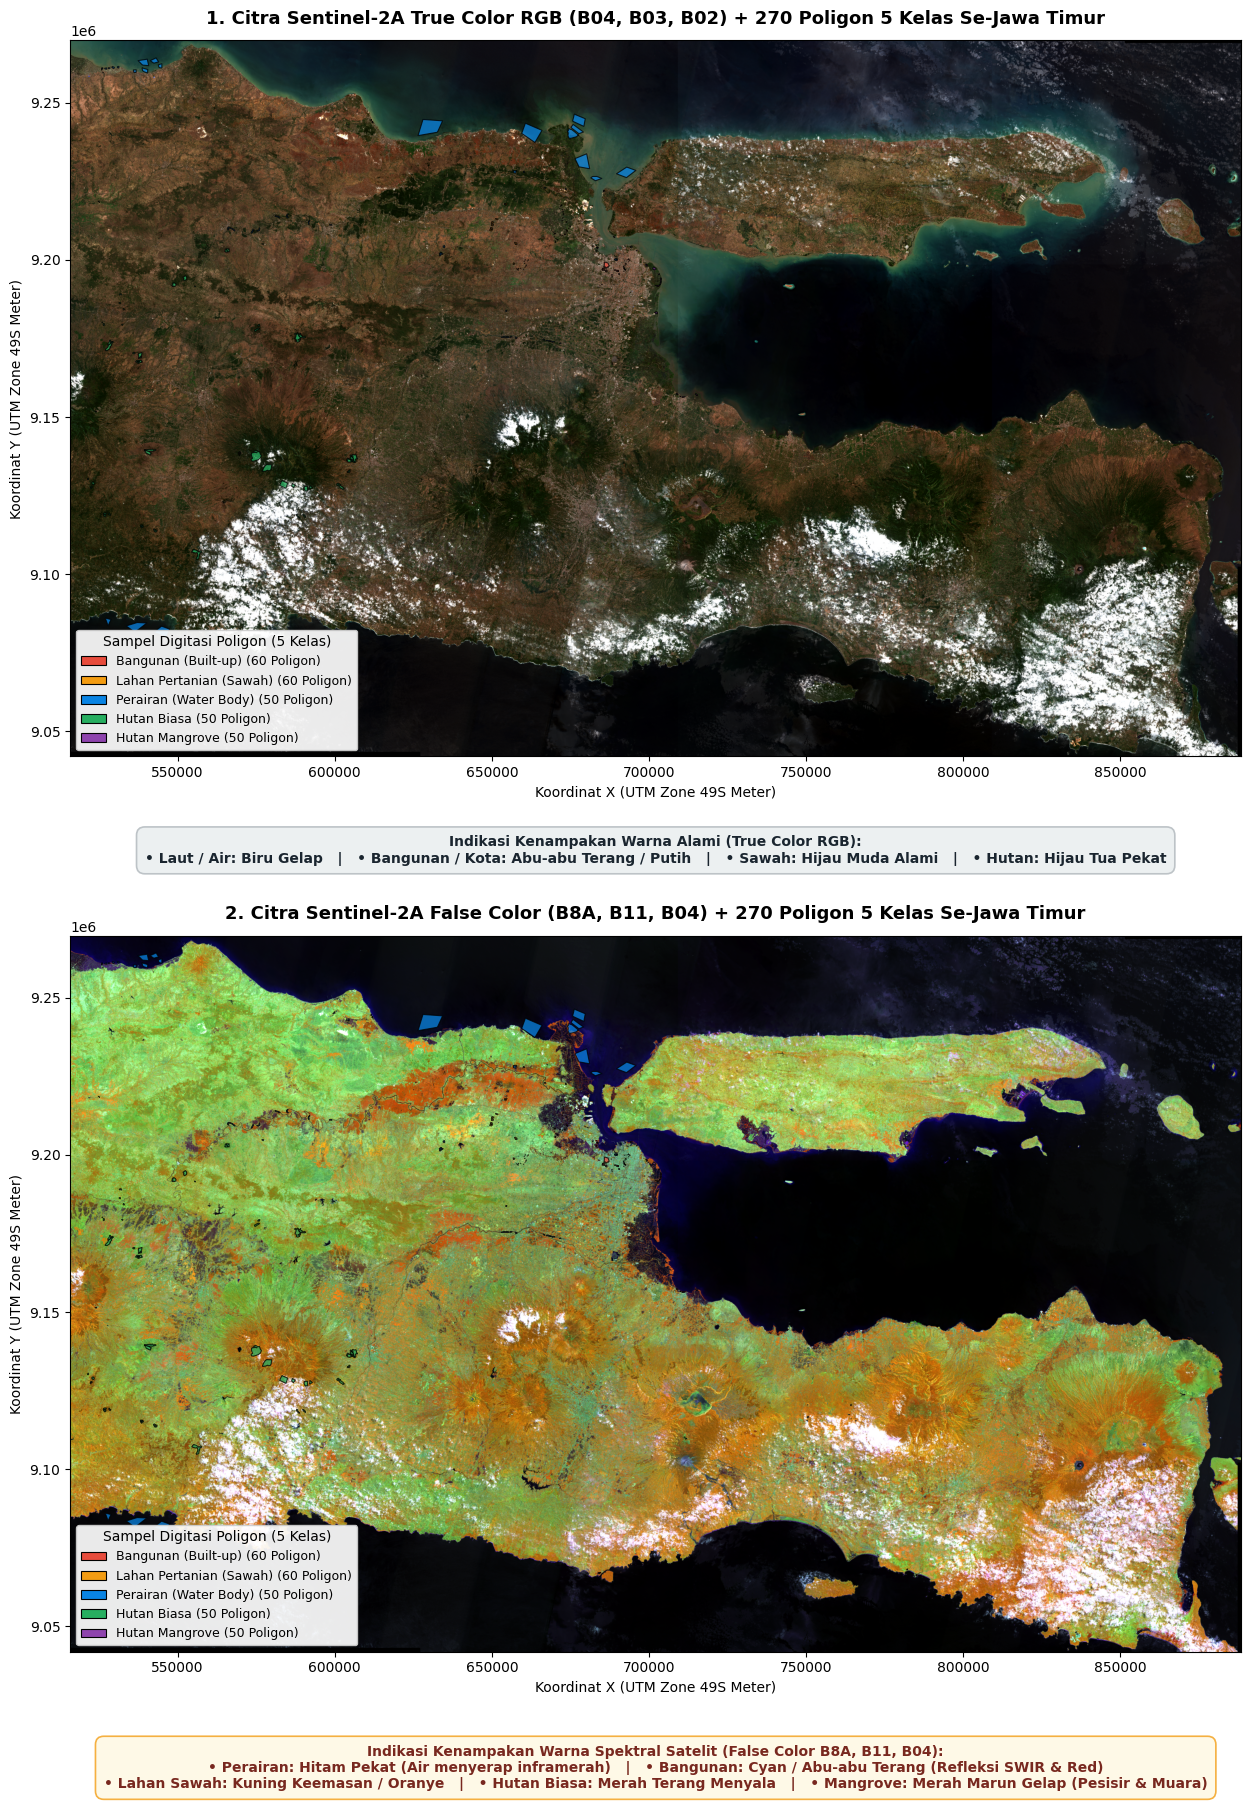

Visualisasi citra satelit Full Jawa Timur (True Color & False Color) dengan indikasi warna di bawahnya berhasil ditampilkan dan disimpan!


In [11]:
if os.path.exists(tif_file):
    import matplotlib.patches as mpatches

    def stretch(band):
        valid = band[band > 0]
        if len(valid) == 0:
            return np.zeros_like(band)
        p2, p98 = np.percentile(valid, (2, 98))
        return np.clip((band - p2) / (p98 - p2 + 1e-6), 0, 1)

    # 1. True Color RGB (B04, B03, B02) - Warna Alami
    rgb_jatim = np.dstack([stretch(b4), stretch(b3), stretch(b2)])

    # 2. False Color Spektral (B8A, B11, B04) - Kontras Spektral Seluruh 5 Kelas
    false_jatim = np.dstack([stretch(b8a), stretch(b11), stretch(b4)])

    # Ambil koordinat batas langsung dari rasterio untuk akurasi posisi 100%
    with rasterio.open(tif_file) as src:
        img_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        raster_crs = src.crs

    # Pastikan poligon GeoJSON dalam CRS yang sama dengan raster (UTM Zone 49S)
    gdf_plot = gdf_all.to_crs(raster_crs) if gdf_all.crs != raster_crs else gdf_all

    fig, axes = plt.subplots(2, 1, figsize=(16, 18))

    # Buat Legend Handles Berwarna untuk Poligon Sampel 5 Kelas
    legend_handles = [
        mpatches.Patch(facecolor=cfg["color"], edgecolor="black", linewidth=0.8,
                       label=f"{cfg['label']} ({summary_counts.get(cfg['label'], 0)} Poligon)")
        for key, cfg in class_configs.items()
    ]

    # --- PETA 1: TRUE COLOR RGB + POLIGON 5 KELAS ---
    axes[0].imshow(rgb_jatim, extent=img_extent)
    axes[0].set_title("1. Citra Sentinel-2A True Color RGB (B04, B03, B02) + 270 Poligon 5 Kelas Se-Jawa Timur", fontsize=13, fontweight="bold", pad=12)
    axes[0].set_xlabel("Koordinat X (UTM Zone 49S Meter)", fontsize=10)
    axes[0].set_ylabel("Koordinat Y (UTM Zone 49S Meter)", fontsize=10)

    for key, cfg in class_configs.items():
        subset = gdf_plot[gdf_plot["kelas_kode"] == key]
        subset.plot(ax=axes[0], color=cfg["color"], edgecolor="black", linewidth=0.8, alpha=0.75)

    axes[0].legend(handles=legend_handles, loc="lower left", framealpha=0.92, title="Sampel Digitasi Poligon (5 Kelas)", fontsize=9, title_fontsize=10)

    # Kotak Indikasi Warna di Bawah Peta 1
    info_peta1 = (
        "Indikasi Kenampakan Warna Alami (True Color RGB):\n"
        "• Laut / Air: Biru Gelap   |   • Bangunan / Kota: Abu-abu Terang / Putih   |   • Sawah: Hijau Muda Alami   |   • Hutan: Hijau Tua Pekat"
    )
    axes[0].text(
        0.5, -0.11, info_peta1,
        transform=axes[0].transAxes,
        ha="center", va="top",
        fontsize=10, fontweight="semibold",
        color="#1a252f",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#ecf0f1", edgecolor="#bdc3c7", linewidth=1.2)
    )

    # --- PETA 2: FALSE COLOR (B8A, B11, B04) + POLIGON 5 KELAS ---
    axes[1].imshow(false_jatim, extent=img_extent)
    axes[1].set_title("2. Citra Sentinel-2A False Color (B8A, B11, B04) + 270 Poligon 5 Kelas Se-Jawa Timur", fontsize=13, fontweight="bold", pad=12)
    axes[1].set_xlabel("Koordinat X (UTM Zone 49S Meter)", fontsize=10)
    axes[1].set_ylabel("Koordinat Y (UTM Zone 49S Meter)", fontsize=10)

    for key, cfg in class_configs.items():
        subset = gdf_plot[gdf_plot["kelas_kode"] == key]
        subset.plot(ax=axes[1], color=cfg["color"], edgecolor="black", linewidth=0.8, alpha=0.75)

    axes[1].legend(handles=legend_handles, loc="lower left", framealpha=0.92, title="Sampel Digitasi Poligon (5 Kelas)", fontsize=9, title_fontsize=10)

    # Kotak Indikasi Warna di Bawah Peta 2
    info_peta2 = (
        "Indikasi Kenampakan Warna Spektral Satelit (False Color B8A, B11, B04):\n"
        "• Perairan: Hitam Pekat (Air menyerap inframerah)   |   • Bangunan: Cyan / Abu-abu Terang (Refleksi SWIR & Red)\n"
        "• Lahan Sawah: Kuning Keemasan / Oranye   |   • Hutan Biasa: Merah Terang Menyala   |   • Mangrove: Merah Marun Gelap (Pesisir & Muara)"
    )
    axes[1].text(
        0.5, -0.13, info_peta2,
        transform=axes[1].transAxes,
        ha="center", va="top",
        fontsize=10, fontweight="semibold",
        color="#78281f",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#fef9e7", edgecolor="#f5b041", linewidth=1.2)
    )

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.25)
    os.makedirs("data/images", exist_ok=True)
    plt.savefig("data/images/visualisasi_full_jatim_60m.png", dpi=180, bbox_inches="tight")
    plt.show()

    print("Visualisasi citra satelit Full Jawa Timur (True Color & False Color) dengan indikasi warna di bawahnya berhasil ditampilkan dan disimpan!")
else:
    print("Silakan unduh citra pada Sel 4 terlebih dahulu.")


## Kesimpulan & Keunggulan Pendekatan 60m

1. **Bebas Crash / Out of Memory**: Mengurangi volume komputasi cloud 36x lipat sehingga cluster gratis Copernicus CDSE dapat menyelesaikannya dengan mulus tanpa memutus pekerjaan.
2. **Cepat**: Hanya memerlukan waktu 2 sampai 4 menit (dibandingkan 10m yang berjalan 22+ menit lalu gagal).
3. **Cakupan 100% Utuh**: Meliputi seluruh wilayah Jawa Timur dari ujung barat (Ngawi/Pacitan) sampai ujung timur (Banyuwangi/Madura) dan mencakup seluruh 270 poligon sampel digitasi.
4. **6 Band Spektral Lengkap**: Mempertahankan band penting `B8A` (Narrow NIR) dan `B11` (SWIR-1) untuk klasifikasi tutupan lahan lanjutan.